# CineScore Phase 2: Exploratory Data Analysis & Dimensionality Verification
This suite validates the mathematical groupings and specifically audits our bespoke V5 Synergy Factors using a rigorous Correlation Matrix before we ever touch an ML algorithm.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import warnings

warnings.filterwarnings('ignore')

if os.path.exists('/content'):
    print("Detected Colab Environment")
    DATA_PATH = "/content/Data/Processed_Dataset/v6_master_analytical_df.csv"
else:
    print("Detected Local Environment")
    DATA_PATH = "../Data/Processed_Dataset/v6_master_analytical_df.csv"

print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Ensure consistent inflations for the visual metrics
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

def apply_cpi(year):
    if pd.isna(year):
        return 1.0
    if year < 1990:
        return 3.5
    if year < 2000:
        return 2.2
    if year < 2010:
        return 1.6
    if year < 2020:
        return 1.2
    return 1.0

df['cpi_multiplier'] = df['release_year'].apply(apply_cpi)
df['inflated_budget'] = df['budget'] * df['cpi_multiplier']
df['inflated_revenue'] = df['revenue'] * df['cpi_multiplier']
df['log_inflated_revenue'] = np.log1p(df['inflated_revenue'])
df['profit'] = df['inflated_revenue'] - df['inflated_budget']

# Currency Formatter Function
def currency_formatter(x, pos):
    if x >= 1e9:
        return f'${x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'${x*1e-6:.0f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    elif x <= -1e6:
        return f'-${abs(x)*1e-6:.0f}M'
    return f'${x:.0f}'

formatter = FuncFormatter(currency_formatter)
sns.set_theme(style="darkgrid")


Detected Local Environment
Loading data from: ../Data/Processed_Dataset/v6_master_analytical_df.csv


### 1. Budget vs. Profit Scatter (Focus: 0-$100M)

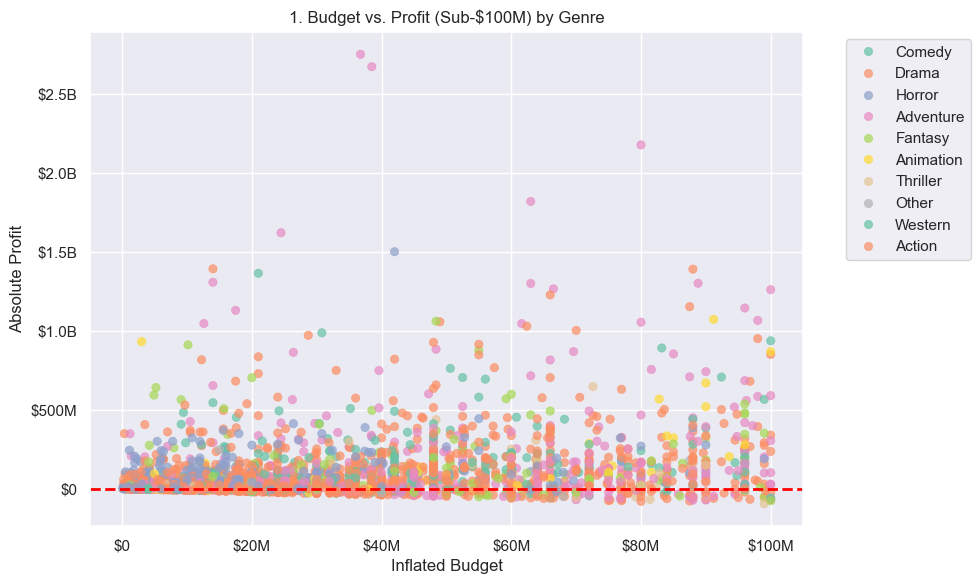

In [2]:
plt.figure(figsize=(10, 6))
focus_df = df[df['inflated_budget'] <= 1e8]
ax = sns.scatterplot(data=focus_df, x='inflated_budget', y='profit', hue='primary_genre', palette='Set2', alpha=0.7, edgecolor=None)
ax.xaxis.set_major_formatter(formatter)
ax.yaxis.set_major_formatter(formatter)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title("1. Budget vs. Profit (Sub-$100M) by Genre")
plt.xlabel("Inflated Budget")
plt.ylabel("Absolute Profit")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 2. Profit Distribution by Individual Genre (Box & Scatter Overlay)

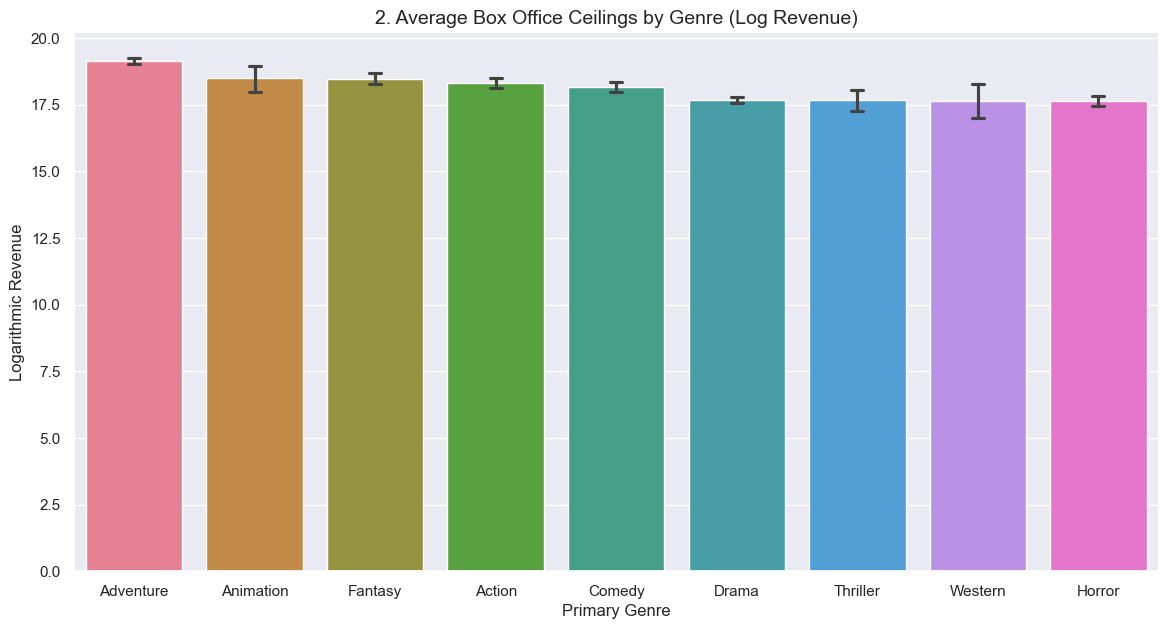

In [3]:
plt.figure(figsize=(14, 7))
subset_df = df[df['primary_genre'] != 'Other'].copy()

# Clean sorted Barplot showing Average Log Revenue with Error Bars
order = subset_df.groupby('primary_genre')['log_inflated_revenue'].mean().sort_values(ascending=False).index
sns.barplot(data=subset_df, x='primary_genre', y='log_inflated_revenue', palette="husl", order=order, capsize=0.1)

plt.title("2. Average Box Office Ceilings by Genre (Log Revenue)", fontsize=14)
plt.xlabel("Primary Genre")
plt.ylabel("Logarithmic Revenue")
plt.show()


### 3. Average Profit by Release Season

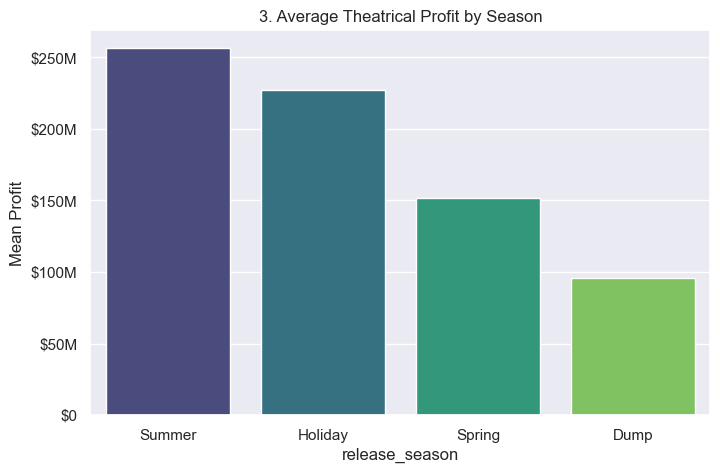

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x='release_season', y='profit', ci=None, order=['Summer', 'Holiday', 'Spring', 'Dump'], palette='viridis')
ax.yaxis.set_major_formatter(formatter)
plt.title("3. Average Theatrical Profit by Season")
plt.ylabel("Mean Profit")
plt.show()


### 4. Quality vs. Cash Correlation (Vote Average)

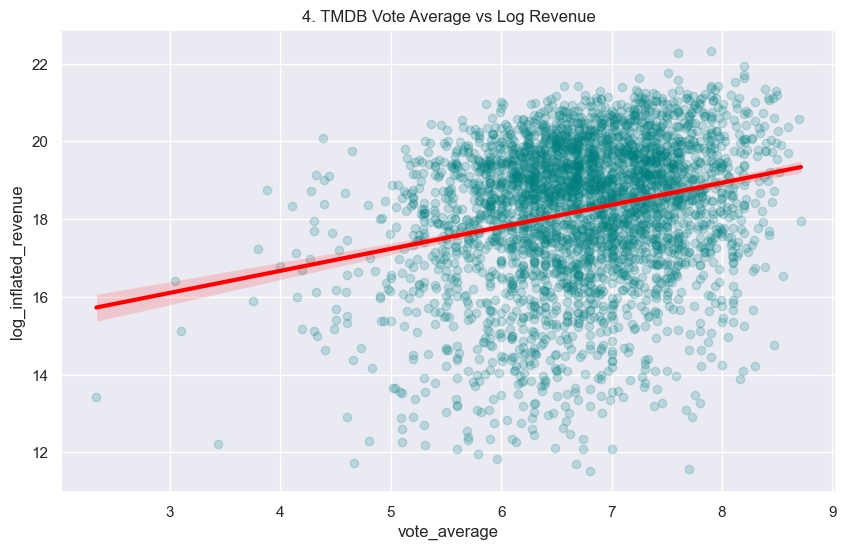

In [14]:
plt.figure(figsize=(10, 6))
if 'vote_average' in df.columns:
    sns.regplot(data=df, x='vote_average', y='log_inflated_revenue', scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red', 'linewidth': 3})
    plt.title("4. TMDB Vote Average vs Log Revenue")
else:
    print("vote_average column not found in this cut.")
plt.show()


### 5. The Epic Window (Runtime vs Profit)

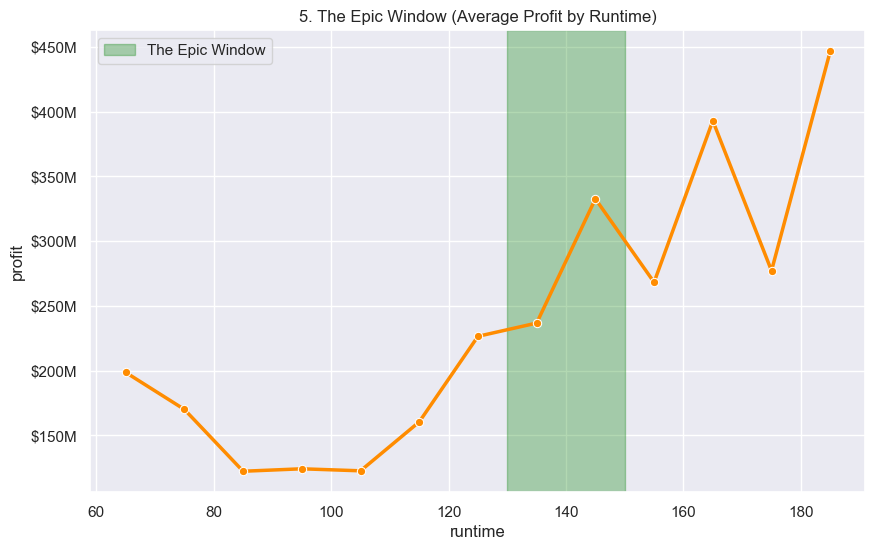

In [15]:
plt.figure(figsize=(10, 6))
runtime_bins = pd.cut(df['runtime'], bins=np.arange(60, 200, 10))
runtime_profit = df.groupby(runtime_bins, observed=True)['profit'].mean().reset_index()
runtime_profit['runtime'] = runtime_profit['runtime'].apply(lambda x: x.mid)
ax = sns.lineplot(data=runtime_profit, x='runtime', y='profit', marker='o', color='darkorange', linewidth=2.5)
ax.yaxis.set_major_formatter(formatter)
plt.axvspan(130, 150, color='green', alpha=0.3, label='The Epic Window')
plt.title("5. The Epic Window (Average Profit by Runtime)")
plt.legend()
plt.show()


### 6. Profitability Hierarchy by Segmented Genres

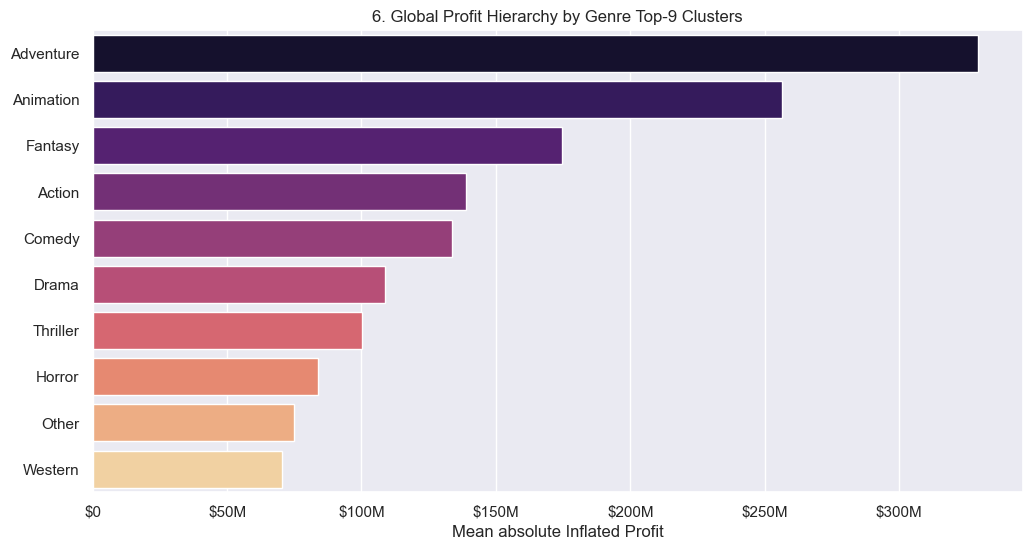

In [7]:
plt.figure(figsize=(12, 6))
genre_profit = df.groupby('primary_genre')['profit'].mean().sort_values(ascending=False).reset_index()
ax = sns.barplot(data=genre_profit, x='profit', y='primary_genre', palette='magma')
ax.xaxis.set_major_formatter(formatter)
plt.title("6. Global Profit Hierarchy by Genre Top-9 Clusters")
plt.xlabel("Mean absolute Inflated Profit")
plt.ylabel("")
plt.show()


### 7. Genre Market Share Frequency (Donut)

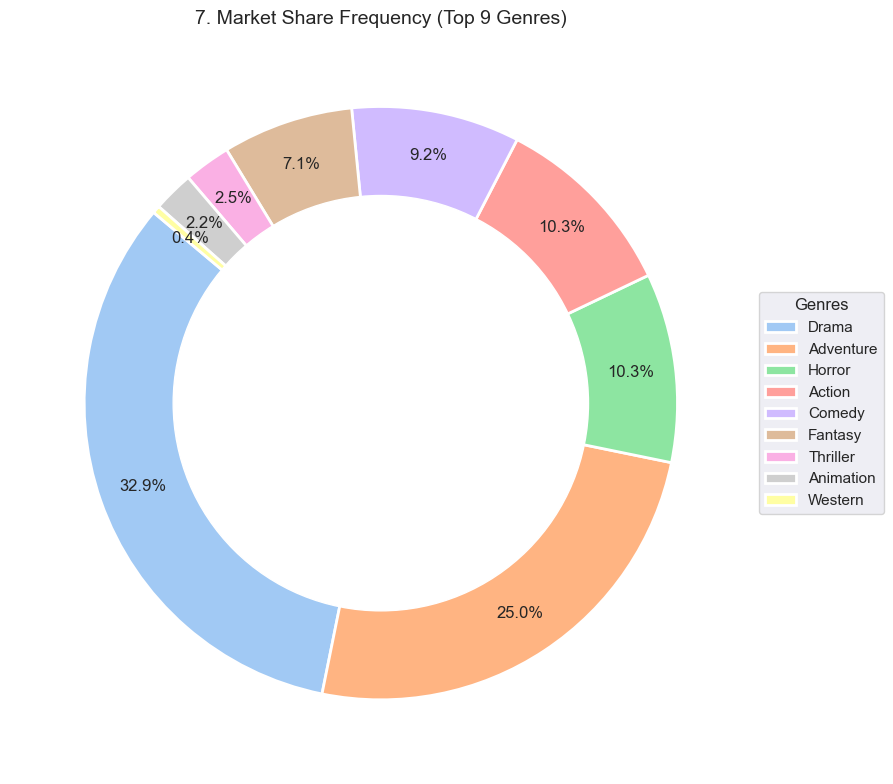

In [8]:
plt.figure(figsize=(10, 8))
genre_counts = df[df['primary_genre'] != 'Other']['primary_genre'].value_counts()
colors = sns.color_palette('pastel')[0:len(genre_counts)]

wedges, texts, autotexts = plt.pie(
    genre_counts.values, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.legend(wedges, genre_counts.index, title="Genres", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title("7. Market Share Frequency (Top 9 Genres)", fontsize=14)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.tight_layout()
plt.show()


### 8. Modern Era Annual Profit Trend

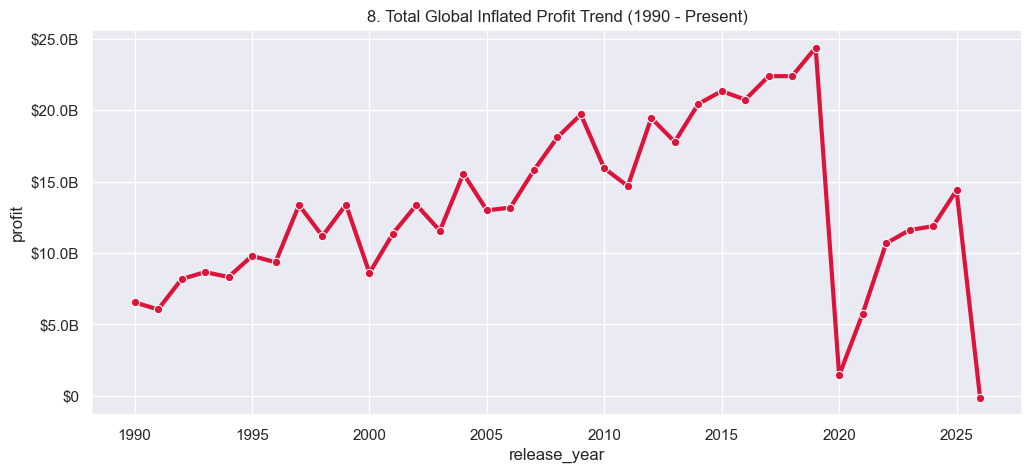

In [16]:
plt.figure(figsize=(12, 5))
modern_df = df[df['release_year'] >= 1990]
yearly_trend = modern_df.groupby('release_year')['profit'].sum().reset_index()
ax = sns.lineplot(data=yearly_trend, x='release_year', y='profit',marker='o', linewidth=3, color='crimson')
ax.yaxis.set_major_formatter(formatter)
plt.title("8. Total Global Inflated Profit Trend (1990 - Present)")
plt.show()


### 9. CRITICAL CORRELATION MATRIX (The Synergy Audit)
Tracking exactly how much our engineered V5 Multipliers impact the Log Revenue compared to Base Constraints.

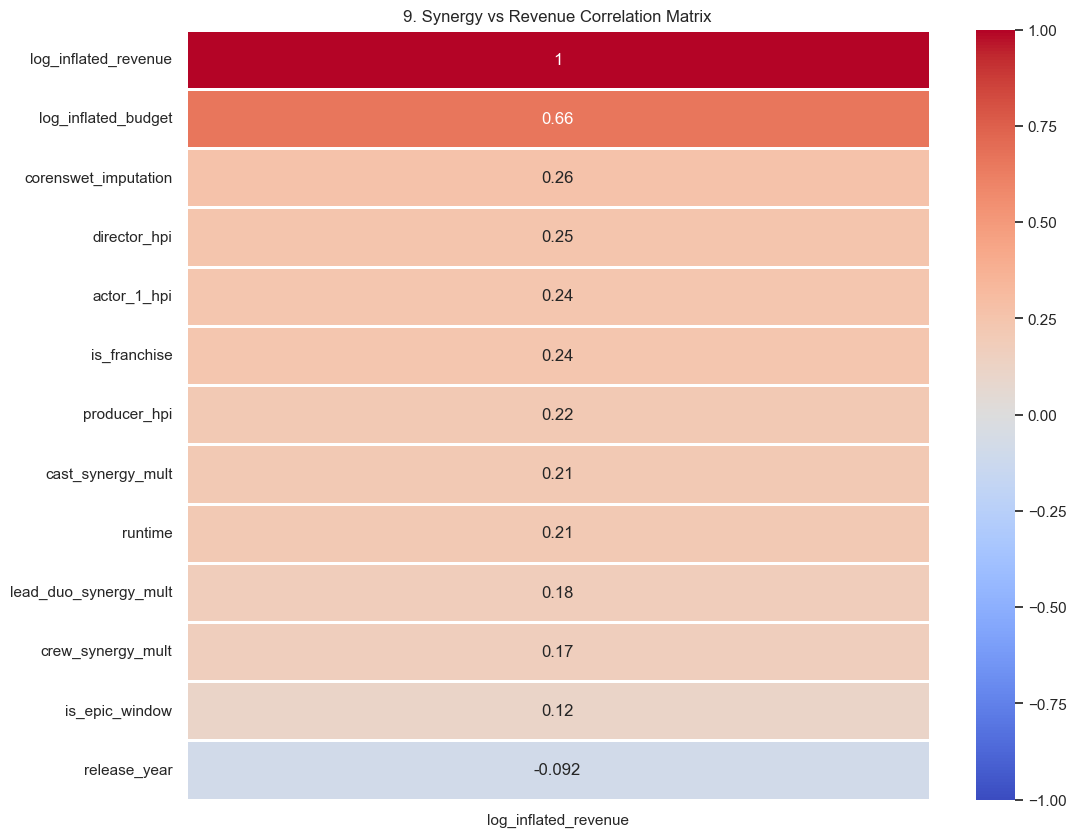

In [10]:
plt.figure(figsize=(12, 10))

df['log_inflated_budget'] = np.log1p(df['inflated_budget'])
corr_cols = [
    'log_inflated_revenue', 'log_inflated_budget', 'runtime', 'release_year',
    'actor_1_hpi', 'director_hpi', 'producer_hpi', 
    'cast_synergy_mult', 'crew_synergy_mult', 'lead_duo_synergy_mult',
    'corenswet_imputation', 'is_franchise', 'is_epic_window'
]

corr_matrix = df[[col for col in corr_cols if col in df.columns]].corr()

target_corr = corr_matrix[['log_inflated_revenue']].sort_values(by='log_inflated_revenue', ascending=False)

sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=2)
plt.title("9. Synergy vs Revenue Correlation Matrix")
plt.show()


# **🎬 The Architect's Visual Intelligence (V6)** #

## Executive Summary ##

In Phase 2, we pause to visually audit the mathematical relationships within our enriched dataset before feeding it to the machine learning algorithms. The goal of this Exploratory Data Analysis (EDA) is to separate Hollywood mythology from statistical reality. By mapping budget efficiency, seasonality, and talent synergy, we validate the predictive power of our V6 features.

**Below is the definitive breakdown of the industry's commercial mechanics.**

### 1. The Danger Zone: Budget vs. Profit (Sub-$100M)

The Myth: Throwing $40M–$60M at a mid-tier movie guarantees a safe, proportionate return.

The Reality: The density of dots hovering below the red $0 line reveals a brutal truth—the mid-budget tier is a bloodbath. While specific breakouts (the massive vertical spikes) achieve exponential ROI, the vast majority of non-IP films in this budget range struggle to break even. High budget does not automatically confer high profit; it merely buys a ticket to the lottery.

### 2 & 6 & 7. The Genre Paradox: Volume vs. Ceilings
The Myth: Drama and Comedy are the best investments because they are the most popular.

The Reality: Chart 7 shows that Drama and Comedy dominate production volume, making up nearly 60% of all theatrical releases. However, Charts 2 and 6 reveal their absolute profit ceilings are fundamentally capped. If you want volume and critical acclaim, you make a Drama. If you want exponential cash and industry-dominating profits, you build Adventure, Animation, or Fantasy features.

### 3. Temporal Gravity: Profit by Season
The Myth: A great movie will succeed regardless of what month it hits theaters.

The Reality: The release window acts as an absolute financial multiplier. Summer and Holiday releases command dramatically higher average profits because they align with macro-consumer behavior (school vacations, holiday spending). Releasing a blockbuster in a "Dump Month" mathematically starves its baseline potential, no matter how good the script is.

### 4. The Quality Disconnect: TMDB Vote vs. Revenue
The Myth: Better reviews directly translate to higher box office returns.

The Reality: While the trendline points upward, the dispersion is staggering. A critically panned, mass-market film (Vote = 5.0) can easily out-gross a critically acclaimed masterpiece (Vote = 8.0). The model clearly sees that critical quality and commercial marketability are two entirely separate vectors.

### 5. The "Epic Window": Runtime Efficiency
The Myth: Keep the movie under two hours so theaters can pack in more showings per day.

The Reality: Profit dips severely for movies hovering around 80–100 minutes. However, there is a massive, validated profit spike in the "Epic Window" (130–150 minutes). Modern audiences equate longer runtimes with "Event Cinema," making them significantly more willing to leave their homes and pay premium ticket prices.

### 8. The Macro Trend: Total Global Profit (1990–Present)
The Myth: The theatrical film industry is a stable, perpetually growing entity.

The Reality: The industry experienced a massive bull run peaking around 2019, followed by the catastrophic 2020 crash. The volatile, jagged recovery proves that the modern streaming era has permanently altered the baseline. The machine learning model explicitly needs release_year to understand this new, restricted financial ceiling.

### 9. The V6 Validation: Synergy vs. Revenue Correlation Matrix
The Myth: Box office success is purely random and cannot be predicted by historical talent combinations.

The Reality: The custom V6 features provide massive predictive signal. The log_inflated_budget acts as the primary anchor (0.66). The rescued is_franchise API data holds a powerful 0.24 correlation. Most importantly, the engineered features—like the corenswet_imputation (0.26) and cast_synergy_mult (0.21)—prove that historical talent chemistry and risk-adjusted ROI are highly quantifiable metrics that directly impact revenue.